Using Colab cache for faster access to the 'amazon-shopping-reviews-daily-updated' dataset.
Dataset Loaded Successfully
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89720 entries, 0 to 89719
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              89720 non-null  object
 1   userName              89714 non-null  object
 2   content               89713 non-null  object
 3   score                 89720 non-null  int64 
 4   thumbsUpCount         89720 non-null  int64 
 5   reviewCreatedVersion  79220 non-null  object
 6   at                    89720 non-null  object
 7   appVersion            79220 non-null  object
dtypes: int64(2), object(6)
memory usage: 5.5+ MB
None

Sentiment Distribution:
Sentiment
Positive    47131
Negative    28212
Neutral     14256
Name: count, dtype: int64


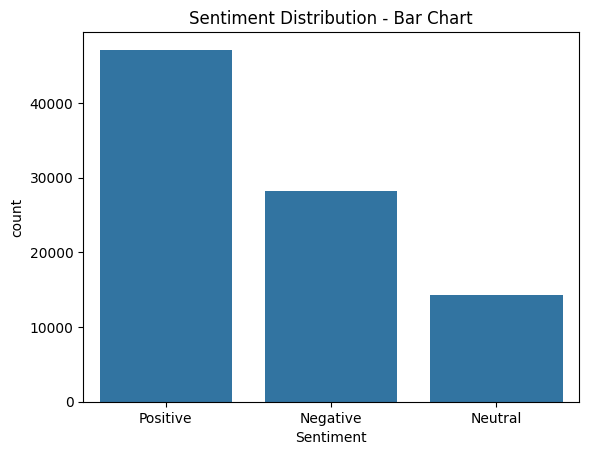

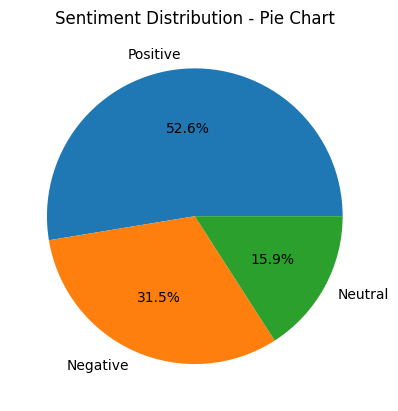

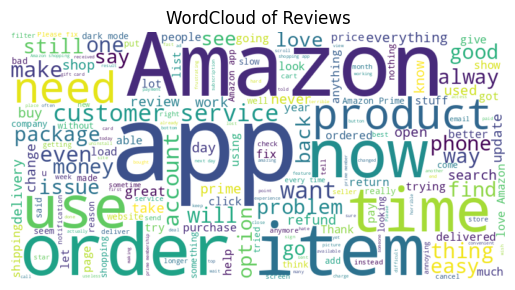


Model Accuracy: 0.8682477678571429

Classification Report:

              precision    recall  f1-score   support

    Negative       0.86      0.83      0.85      5710
     Neutral       0.81      0.87      0.84      2925
    Positive       0.89      0.89      0.89      9285

    accuracy                           0.87     17920
   macro avg       0.85      0.86      0.86     17920
weighted avg       0.87      0.87      0.87     17920


Confusion Matrix:

[[4723  236  751]
 [ 112 2533  280]
 [ 626  356 8303]]


In [2]:
# ==============================
# 1. Install Required Libraries
# ==============================
# (Run only once if needed)
# !pip install kagglehub matplotlib seaborn wordcloud nltk textblob scikit-learn

# ==============================
# 2. Import Libraries
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from textblob import TextBlob
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from warnings import filterwarnings
filterwarnings('ignore')

# ==============================
# 3. Load Dataset
# ==============================
import kagglehub

path = kagglehub.dataset_download("ashishkumarak/amazon-shopping-reviews-daily-updated")
df = pd.read_csv(path + "/amazon_reviews.csv")

print("Dataset Loaded Successfully")
print(df.info())

# ==============================
# 4. Remove Duplicates
# ==============================
df = df.drop_duplicates()

# ==============================
# 5. Handle Missing Values
# ==============================
df = df.dropna(subset=["content"])

if "score" in df.columns:
    df["score"].fillna(df["score"].median(), inplace=True)

# ==============================
# 6. Create Sentiment Labels
# ==============================
def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    if polarity > 0:
        return "Positive"
    elif polarity == 0:
        return "Neutral"
    else:
        return "Negative"

df["Sentiment"] = df["content"].apply(get_sentiment)

print("\nSentiment Distribution:")
print(df["Sentiment"].value_counts())

# ==============================
# 7. Visualization
# ==============================

# ---- Bar Chart ----
plt.figure()
sns.countplot(x="Sentiment", data=df)
plt.title("Sentiment Distribution - Bar Chart")
plt.show()

# ---- Pie Chart ----
plt.figure()
df["Sentiment"].value_counts().plot.pie(autopct="%1.1f%%")
plt.title("Sentiment Distribution - Pie Chart")
plt.ylabel("")
plt.show()

# ---- WordCloud ----
text_data = " ".join(df["content"].astype(str))

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text_data)

plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud of Reviews")
plt.show()

# ==============================
# 8. Machine Learning Model
# ==============================

# Features and Target
X = df["content"]
y = df["Sentiment"]

# Convert text into TF-IDF
vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
X = vectorizer.fit_transform(X)

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# ==============================
# 9. Evaluation
# ==============================
print("\nModel Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))